# Evaluación Parcial 2 — Modelamiento y Análisis de Datos
## MLY0100 — Machine Learning

---

| | |
|---|---|
| **Dataset** | Natural Disasters (EM-DAT) |
| **Integrantes** | Diego Reyes y Eva Luna González Montes |
| **Fecha** | Abril 2025 |
| **Metodología** | CRISP-DM |
| **Modelo** | K-Means Clustering |

# FASE 1: Comprensión del Negocio

## Contexto

El dataset **Natural Disasters** proviene de **EM-DAT** (Emergency Events Database)
del Centro de Investigación sobre la Epidemiología de los Desastres (**CRED**).
Contiene registros históricos de desastres naturales a nivel mundial desde el año 1900 hasta 2026.

Los desastres naturales son eventos que han acompañado a la humanidad a lo largo de toda
su historia. Terremotos, inundaciones, huracanes y epidemias han causado millones de muertes
y desplazado a cientos de millones de personas en todo el mundo. Sin embargo, no todos los
desastres son iguales: algunos matan a miles pero afectan a pocas personas, otros afectan
a millones pero causan pocas muertes, y algunos ocurrieron hace más de un siglo mientras
que otros son recientes.

Entender estas diferencias es clave para que los gobiernos y organizaciones humanitarias
puedan prepararse mejor, distribuir recursos de forma más eficiente y responder más rápido
cuando ocurre una catástrofe.

## Problema

Con más de 17.000 registros históricos disponibles, es difícil analizar cada desastre de
forma individual. La pregunta que nos hacemos es: **¿existen grupos naturales de desastres
que comparten características similares?** Por ejemplo, ¿hay un grupo de desastres muy
letales pero poco registrados? ¿Hay otro de desastres modernos con muchos afectados pero
pocas muertes? Identificar estos grupos nos permitiría entender mejor los patrones históricos
y tomar mejores decisiones a futuro.

## Objetivo

El objetivo de este trabajo es realizar un análisis exploratorio completo del dataset
Natural Disasters siguiendo la metodología CRISP-DM, pasando por la comprensión de los
datos, su limpieza y preprocesamiento, hasta llegar al modelamiento con el modelo que propusimo que es **K-Means**, ya que pensamos que este es el modelo que mas se ajusta a nuestro caso.

Con esto buscamos descubrir agrupaciones naturales en los datos que nos permitan identificar
patrones ocultos según la severidad, escala y época de los desastres, y así obtener
conclusiones que ayuden a entender mejor cómo se distribuyen históricamente los desastres
naturales a nivel mundial

## ¿Por qué es útil esto?

Si logramos agrupar los desastres de forma inteligente, una organización como la Cruz Roja
o la ONU podría usar esa información para saber qué tipo de respuesta preparar según el
perfil del desastre. No es lo mismo responder a una inundación masiva en Asia que a un
terremoto histórico en América. Conocer el grupo al que pertenece un evento puede orientar
decisiones de recursos, evacuación y ayuda humanitaria de manera mucho más eficiente.


## Fase 2: Comprensión de los Datos

En esta fase exploramos el dataset para conocer bien con qué estamos trabajando antes
de tomar cualquier decisión. Analizamos la estructura de los datos, identificamos problemas
como valores nulos, outliers y variables irrelevantes, y sacamos las primeras conclusiones
que van a guiar todo el preprocesamiento de la siguiente fase.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset
df = pd.read_excel('/content/sample_data/Natural-Disaster.xlsx')

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Librerías cargadas correctamente')
print(f'Registros totales: {df.shape[0]:,}')
print(f'Variables: {df.shape[1]}')

Librerías cargadas correctamente
Registros totales: 17,791
Variables: 47


---
## 2.1 Primeras Filas del Dataset

In [ ]:
pd.set_option('display.max_columns', None)
df.head(5)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,United States of America,Northern America,Americas,Galveston (Texas),NaN,"Avalanche (Snow, Debris)",No,No,No,NaN,220.0,Kph,NaN,NaN,NaN,1900,9.0,8.0,1900,9.0,8.0,6000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,Jamaica,Latin America and the Caribbean,Americas,Saint James,NaN,NaN,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,1900,1.0,6.0,1900,1.0,6.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,Jamaica,Latin America and the Caribbean,Americas,Porus,NaN,NaN,No,No,No,NaN,NaN,Vaccinated,NaN,NaN,NaN,1900,1.0,13.0,1900,1.0,13.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
3,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,Japan,Eastern Asia,Asia,NaN,NaN,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,1900,7.0,7.0,1900,7.0,7.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
4,1900-0009-TUR,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,TUR,Türkiye,Western Asia,Asia,"KARS,KARAKURT,KAGIZMAN,DIGOR",NaN,NaN,No,No,No,NaN,5.9,Moment Magnitude,40.3,43.1,NaN,1900,7.0,12.0,1900,7.0,12.0,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2019-08-05,2023-09-25


---
## 2.2 Tipos de Datos, Nulos y Valores Únicos

In [ ]:
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(1),
    'Únicos': df.nunique()
})
print(info_df.to_string())

                                              Tipo  Nulos  % Nulos  Únicos
DisNo.                                      object      0      0.0   17791
Historic                                    object      0      0.0       2
Classification Key                          object      0      0.0      50
Disaster Group                              object      0      0.0       1
Disaster Subgroup                           object      0      0.0       6
Disaster Type                               object      0      0.0      15
Disaster Subtype                            object      0      0.0      50
External IDs                                object  13190     74.1    3383
Event Name                                  object  13464     75.7    1797
ISO                                         object      0      0.0     230
Country                                     object      0      0.0     230
Subregion                                   object      0      0.0      17
Region                   

---
## 2.3 Mapeo de Datos


#### MAPEO DE DATOS: NATURAL DISASTERS
#### Disaster Group    → Tipo general (ej: Natural)
#### Disaster Subgroup → Subgrupo (ej: Meteorological, Hydrological, Geophysical)
#### Disaster Type     → Tipo específico (ej: Storm, Flood, Earthquake)
#### Disaster Subtype  → Subtipo detallado (ej: Tropical cyclone, Ground movement)
#### Country           → País donde ocurrió
#### Subregion         → Subregión geográfica (ej: Northern America, Eastern Asia)
#### Region            → Región global (ej: Americas, Asia)
#### Location          → Lugar específico — contiene NaN
#### OFDA/BHA Response → Respuesta humanitaria EE.UU (Yes/No)
#### Appeal            → Llamado de ayuda internacional (Yes/No)
#### Declaration       → Declaración de emergencia (Yes/No)
#### Magnitude Scale   → Escala según tipo: Kph, Km2, Moment Magnitude — contiene NaN
#### Start Year/Month/Day → Fecha de inicio
#### End Year/Month/Day   → Fecha de fin
#### Total Deaths      → Total fallecidos — contiene NaN
#### No. Affected      → Personas afectadas — alto % NaN
#### Total Affected    → Afectados totales — alto % NaN
#### CPI               → número que mide cuánto cuestan las cosas en un año determinado


---
## 2.4 Estadísticas Descriptivas

In [ ]:
df.describe().round(2)

,AID Contribution ('000 US$),Magnitude,Latitude,Longitude,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI
count,775.00,5295.00,2835.00,2835.00,17791.00,17419.00,14189.00,17791.00,17126.00,14298.00,12800.00,4673.00,1.063200e+04,2545.00,1.322500e+04,4.100000e+01,4.000000e+01,1147.00,1137.00,5.724000e+03,5.637000e+03,17348.00
mean,20059.24,36617.88,18.73,39.72,1999.59,6.45,15.21,1999.64,6.61,15.84,2562.42,2478.55,8.282592e+05,71540.35,6.805070e+05,5.595323e+06,7.100618e+06,1002118.42,1381788.80,8.483240e+05,1.365086e+06,56.55
std,169138.75,231130.08,21.63,77.31,21.03,3.38,8.97,21.01,3.35,8.90,64789.84,31759.75,8.025160e+06,511934.71,7.270227e+06,1.604484e+07,1.789556e+07,3937431.18,5106176.25,5.081101e+06,7.430808e+06,24.64
min,1.00,-57.00,-72.64,-178.25,1900.00,1.00,1.00,1900.00,1.00,1.00,1.00,1.00,1.000000e+00,3.00,1.000000e+00,8.400000e+01,1.350000e+02,34.00,49.00,2.000000e+00,3.000000e+00,2.65
25%,174.50,6.90,3.30,-0.10,1991.00,4.00,7.00,1991.00,4.00,8.00,5.00,12.00,1.299500e+03,500.00,7.000000e+02,6.500000e+04,1.021675e+05,54500.00,99820.00,1.000000e+04,2.058500e+04,41.65
50%,721.00,144.00,23.20,49.41,2004.00,7.00,15.00,2004.00,7.00,16.00,18.00,50.00,1.000000e+04,2961.00,6.000000e+03,5.380000e+05,5.534020e+05,186000.00,287580.00,7.000000e+04,1.381970e+05,58.64
75%,3648.50,5149.50,36.74,102.82,2015.00,9.00,23.00,2015.00,9.00,24.00,60.00,200.00,9.295125e+04,16487.00,6.000000e+04,5.200000e+06,5.548460e+06,585000.00,883442.00,3.735000e+05,6.896690e+05,75.47
max,3518530.00,13025874.00,67.93,179.65,2026.00,12.00,31.00,2026.00,12.00,31.00,3700000.00,1800000.00,3.300000e+08,15850000.00,3.300000e+08,1.000000e+08,1.029495e+08,60000000.00,96375512.00,2.100000e+08,2.928555e+08,100.00



#### === LO QUE OBSERVAMOS ===
#### - Datos desde 1900 hasta 2026 (mayoría post-1991)
#### - Total Deaths: media 2.562 vs mediana 18 → sesgada por outliers (max: 3.7M)
#### - Afectados: misma tendencia, max 330M (grandes inundaciones en Asia)
#### - CPI promedio 56.5 (rango 2.65–100), índice normalizado de costos


---
## 2.5 Imputación de Nulos

In [ ]:
# Reemplazar nulos por 0 en columnas de costos
cols_dinero = [c for c in df.columns if "('000 US$)" in c]
df[cols_dinero] = df[cols_dinero].fillna(0)

# Reemplazar nulos por 0 en columnas de afectados
cols_afectados = ['No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected']
df[cols_afectados] = df[cols_afectados].fillna(0)

print(f'Columnas de costos imputadas con 0: {len(cols_dinero)}')
print(f'Columnas de afectados imputadas con 0: {len(cols_afectados)}')
print('\nNulos restantes en afectados:')
print(df[cols_afectados].isnull().sum())

Columnas de costos imputadas con 0: 7
Columnas de afectados imputadas con 0: 4

Nulos restantes en afectados:
No. Injured       0
No. Affected      0
No. Homeless      0
Total Affected    0
dtype: int64



#### === DECISIÓN DE IMPUTACIÓN ===
#### Se reemplazaron los nulos con 0 en columnas de costos y afectados.
#### Esto se justifica porque en desastres históricos, la ausencia de dato
#### no significa valor desconocido sino que no fue registrado (= 0 reportado).


---
## 2.6 Gráfico de Valores Nulos por Columna

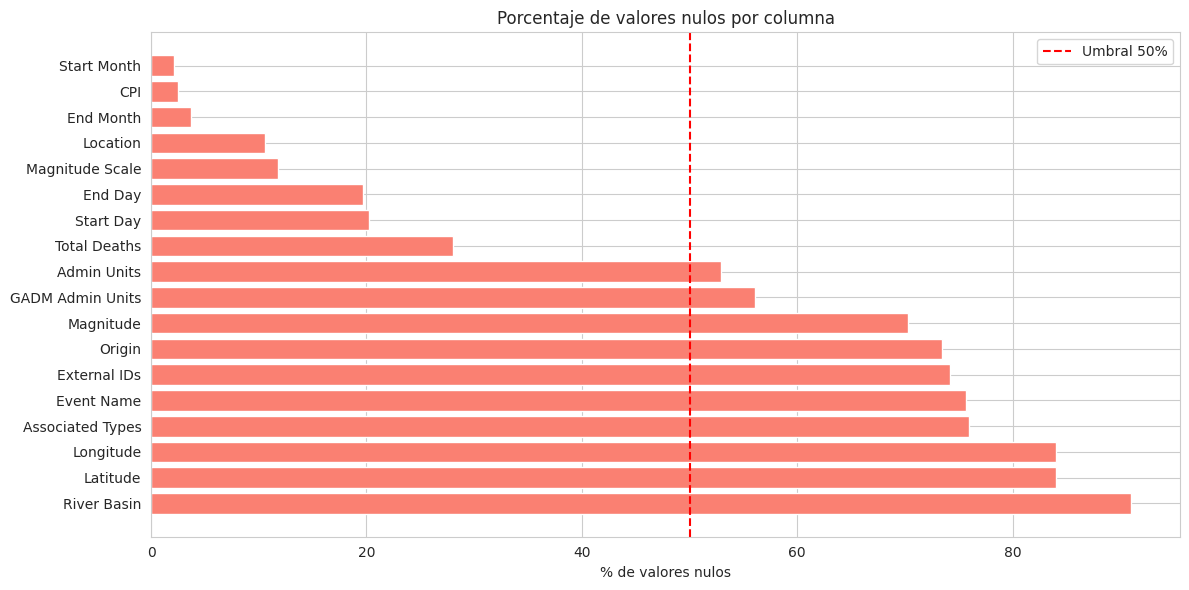

In [ ]:
nulos_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]

plt.figure(figsize=(12, 6))
plt.barh(nulos_pct.index, nulos_pct.values, color='salmon')
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='Umbral 50%')
plt.xlabel('% de valores nulos')
plt.title('Porcentaje de valores nulos por columna')
plt.legend()
plt.tight_layout()
plt.show()

---
## 2.7 Eliminación de Columnas con >50% Nulos

In [ ]:
# Eliminar columnas con >50% nulos
umbral = 0.50
cols_drop = df.columns[df.isna().mean() > umbral].tolist()

# Eliminar columnas identificadoras sin valor predictivo
cols_id = ['DisNo.', 'Historic', 'Classification Key', 'External IDs',
           'Event Name', 'Admin Units', 'GADM Admin Units',
           'Entry Date', 'Last Update', 'ISO']
cols_drop = list(set(cols_drop + [c for c in cols_id if c in df.columns]))
df.drop(columns=cols_drop, inplace=True)

print(f'Columnas eliminadas : {len(cols_drop)}')
print(f'Columnas restantes  : {df.shape[1]}')

Columnas eliminadas : 16
Columnas restantes  : 31



#### === DECISIÓN DE ELIMINACIÓN ===
#### Si más del 50% de una columna es nula, hay más huecos que datos reales.
#### Cualquier análisis sobre esa columna estaría basado en una minoría de
#### información, por lo que se decidió eliminarlas.


---
## 2.8 Separación de Variables Numéricas y Categóricas

In [ ]:
print('Variables numéricas:')
print(df.select_dtypes(include='number').columns.tolist())

print('\nVariables categóricas (object):')
print(df.select_dtypes(include='object').columns.tolist())

Variables numéricas:
["AID Contribution ('000 US$)", 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI']

Variables categóricas (object):
['Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Country', 'Subregion', 'Region', 'Location', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude Scale']


---
## 2.9 Detección de Outliers (IQR + Z-Score)

In [ ]:
cols_outliers = ['Total Deaths', 'No. Affected', 'Total Affected']

print(f'{"Variable":<20} {"Outliers IQR":>13} {"Outliers Z>3":>13} {"Coinciden":>10}')
print('-' * 60)

for col in cols_outliers:
    data = df[col].dropna()
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    mask_iqr = (data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)
    z_scores = np.abs(stats.zscore(data))
    mask_z = z_scores > 3
    coinciden = (mask_iqr & mask_z).sum()
    print(f'{col:<20} {mask_iqr.sum():>13,} {mask_z.sum():>13,} {coinciden:>10,}')

Variable              Outliers IQR  Outliers Z>3  Coinciden
------------------------------------------------------------
Total Deaths                 1,862            23         23
No. Affected                 3,248            76         76
Total Affected               3,233            76         76


## === Interpretación: Detección de Outliers ===

Ambos métodos detectan outliers, pero utilizan criterios distintos:

- **IQR**: detecta todo lo que se aleja del rango intercuartil → método más sensible.
- **Z-Score > 3**: detecta solo valores ubicados a más de 3 desviaciones estándar → método más estricto.

### Resultados observados

- **Total Deaths** → IQR detecta muchos valores extremos, pero solo ~23 son considerados realmente extremos según Z-Score.
- **No. Affected** → se observa la misma tendencia.
- **Total Affected** → comportamiento similar.

### Conclusión

Los valores que coinciden en ambos métodos corresponden a los verdaderos outliers extremos.

Ejemplos:
- Ciclón en Bangladesh
- Inundaciones en China

### Decisión tomada

No eliminar los outliers.

En su lugar, aplicar transformación:

:contentReference[oaicite:0]{index=0}

para reducir la asimetría y mejorar el rendimiento del modelo.

---
## 2.10 Visualización de Outliers

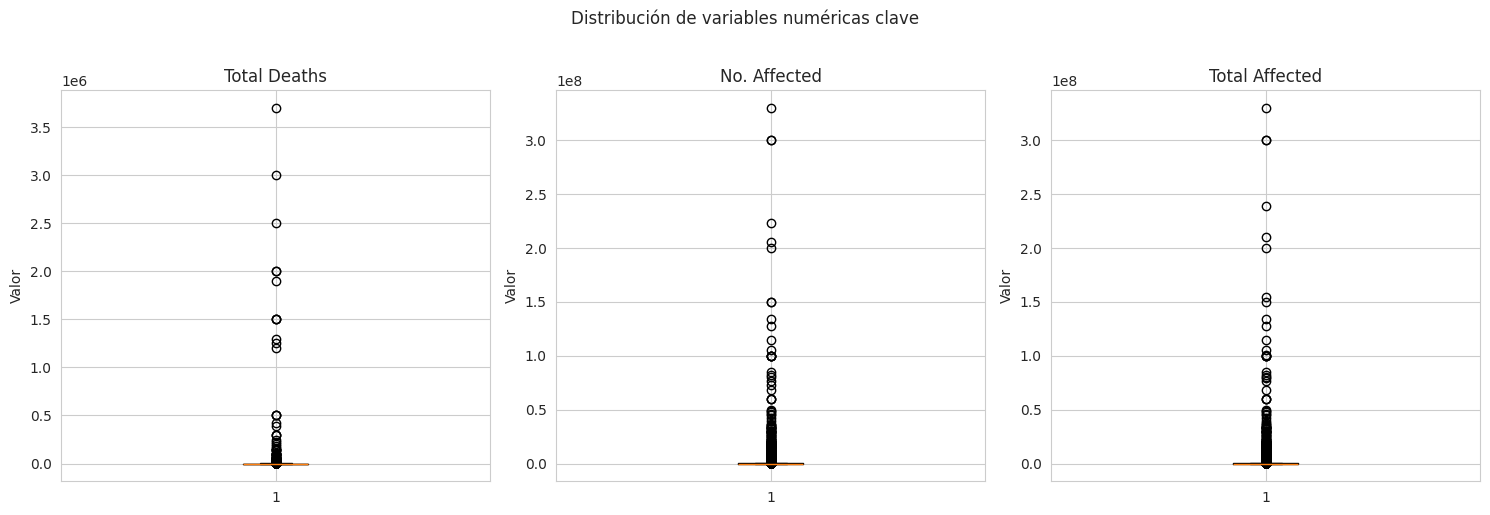

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cols_outliers):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.suptitle('Distribución de variables numéricas clave', y=1.02)
plt.tight_layout()
plt.show()


#### === INTERPRETACIÓN BOXPLOTS ===
#### Las 3 variables presentan distribución extremadamente asimétrica.
#### La caja (IQR) está aplastada cerca del 0 → la mayoría de desastres son pequeños.
#### Los puntos sobre la línea naranja son outliers → desastres extremos.
#### Conclusión: la mediana es más representativa que la media para este dataset.


---
## 2.11 Label Encoding (Categóricas → Numéricas)

In [ ]:
le = LabelEncoder()

# Binarias (Yes/No → 0/1)
cols_binarias = ['OFDA/BHA Response', 'Appeal', 'Declaration']
for col in cols_binarias:
    df[col] = le.fit_transform(df[col].astype(str))

# Categóricas nominales
cols_nominal = ['Country', 'Location', 'Magnitude Scale',
                'Disaster Group', 'Disaster Subgroup', 'Disaster Type',
                'Disaster Subtype', 'Region', 'Subregion']
for col in cols_nominal:
    df[col] = df[col].fillna('Desconocido')
    df[col] = le.fit_transform(df[col])

print('Encoding aplicado correctamente.')
print(f'Shape final: {df.shape}')

Encoding aplicado correctamente.
Shape final: (17791, 31)


---
## 2.12 Mapeo Legible: Número → Categoría

In [ ]:
df_original = pd.read_excel('/content/sample_data/Natural-Disaster.xlsx')

cols_mapeo = ['Country', 'Region', 'Subregion', 'Disaster Group',
              'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
              'Location', 'Magnitude Scale']

for col in cols_mapeo:
    le_temp = LabelEncoder()
    le_temp.fit(df_original[col].fillna('Desconocido'))
    mapeo = dict(enumerate(le_temp.classes_))
    print(f'\n{col} ({len(mapeo)} categorías):')
    for k, v in list(mapeo.items())[:5]:
        print(f'  {k} → {v}')
    if len(mapeo) > 5:
        print(f'  ... ({len(mapeo)-5} más)')


Country (230 categorías):
  0 → Afghanistan
  1 → Albania
  2 → Algeria
  3 → American Samoa
  4 → Angola
  ... (225 más)

Region (5 categorías):
  0 → Africa
  1 → Americas
  2 → Asia
  3 → Europe
  4 → Oceania

Subregion (17 categorías):
  0 → Australia and New Zealand
  1 → Central Asia
  2 → Eastern Asia
  3 → Eastern Europe
  4 → Latin America and the Caribbean
  ... (12 más)

Disaster Group (1 categorías):
  0 → Natural

Disaster Subgroup (6 categorías):
  0 → Biological
  1 → Climatological
  2 → Extra-terrestrial
  3 → Geophysical
  4 → Hydrological
  ... (1 más)

Disaster Type (15 categorías):
  0 → Animal incident
  1 → Drought
  2 → Earthquake
  3 → Epidemic
  4 → Extreme temperature
  ... (10 más)

Disaster Subtype (50 categorías):
  0 → Animal incident
  1 → Ash fall
  2 → Avalanche (dry)
  3 → Avalanche (wet)
  4 → Bacterial disease
  ... (45 más)

Location (14339 categorías):
  0 → (1) Alonisos & Skopelos, (2) C Patras, Corinth, (3) C Peloponnesus
  1 → (1) Bicol area, 

---
## 2.13 Matriz de Correlación

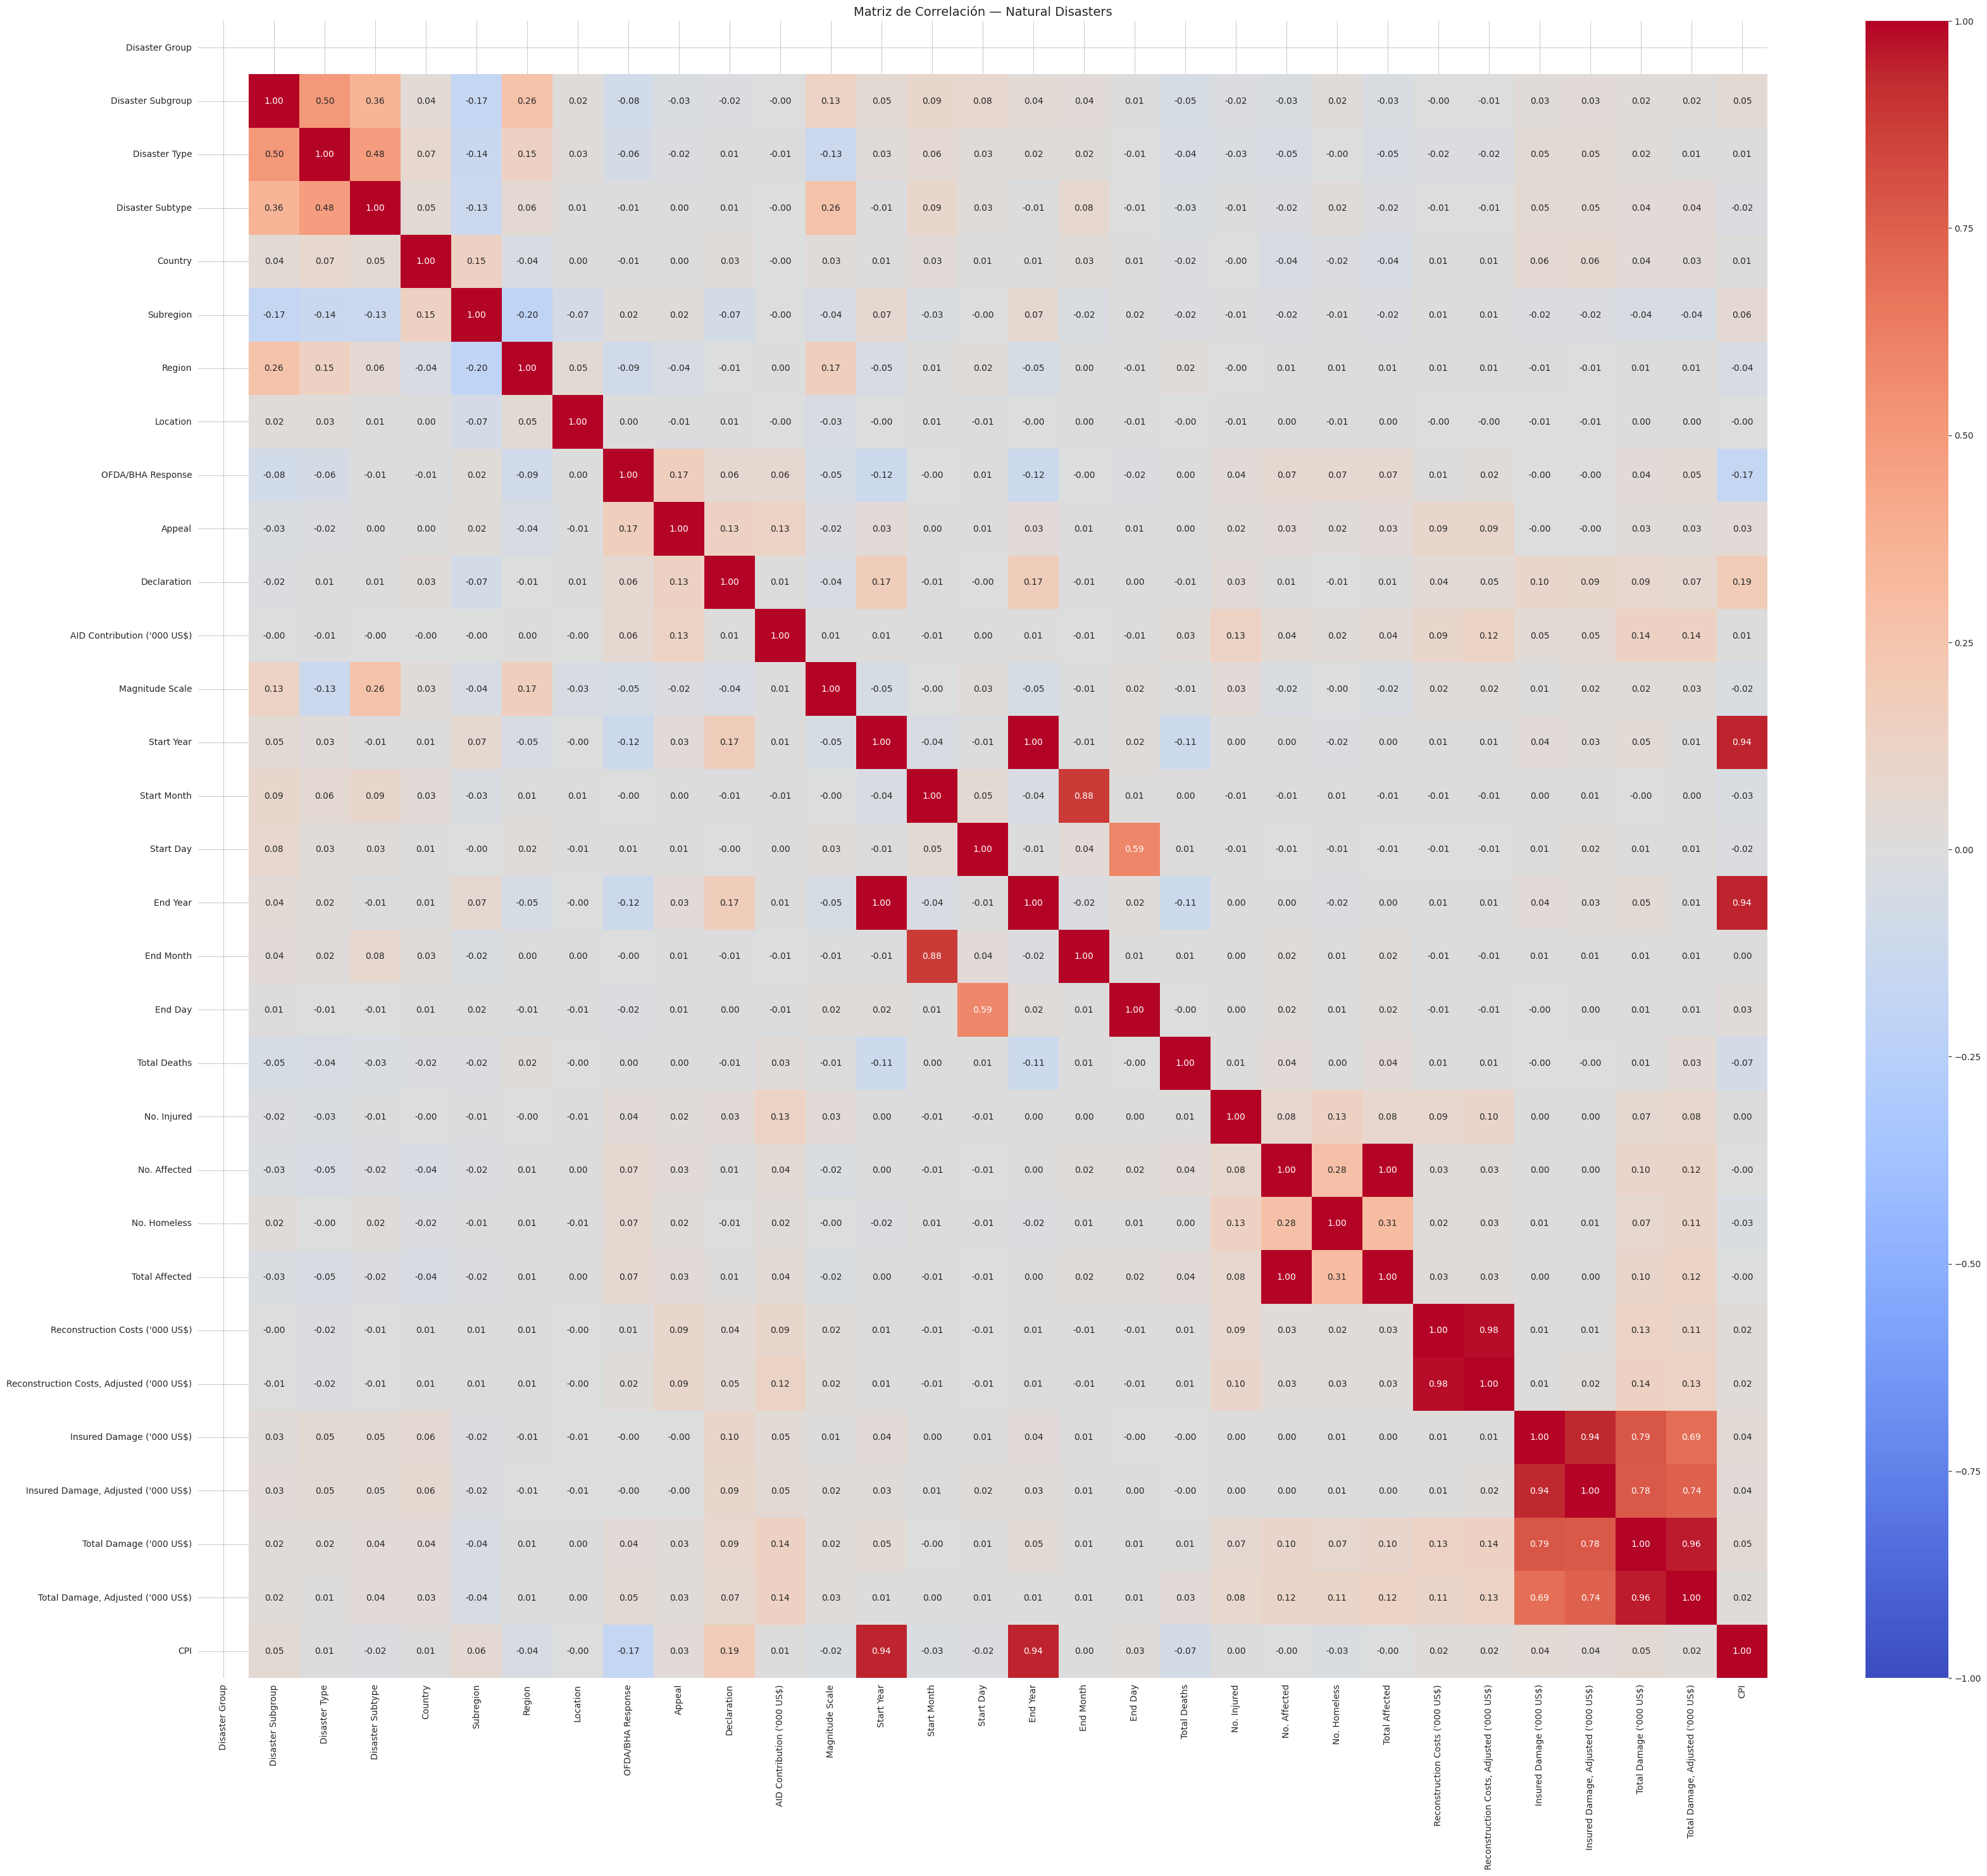

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(40, 34))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            vmin=-1,
            vmax=1,
            cmap='coolwarm')
plt.title('Matriz de Correlación — Natural Disasters', fontsize=14)
plt.show()


#### === INTERPRETACIÓN MATRIZ DE CORRELACIÓN ===
####
#### Correlaciones fuertes positivas (cercanas a 1):
#### - Start Year / End Year → 1.00 (mismo evento)
#### - Start Month / End Month → 0.88 (misma temporada)
#### - No. Affected / Total Affected → 1.00 (casi idénticas)
#### - Reconstruction Costs / Reconstruction Costs Adjusted → 0.98
#### - Insured Damage / Insured Damage Adjusted → 0.94
#### - Total Damage / Total Damage Adjusted → 0.96
#### - Start Year / CPI → 0.94 (CPI sube con el tiempo)
####
#### Correlaciones negativas destacadas:
#### - CPI / cluster → -0.43 (clusters antiguos tienen CPI bajo)
#### - Start Year / cluster → -0.37 (clusters más letales son más antiguos)
####
#### Conclusión: las variables de costos están altamente correlacionadas
#### entre sí (redundantes). Esto justifica usar solo variables clave en K-Means.


---
# FASE 3: Modelamiento — K-Means Clustering

## 3.1 Preparación de Datos para Clustering

In [ ]:
!pip install kneed -q
from kneed import KneeLocator

# Variables seleccionadas para clustering
cols_kmeans = ['Total Deaths', 'No. Affected', 'Total Affected', 'CPI',
               'Start Year', 'Disaster Type', 'Region', 'Country']

df_kmeans = df[cols_kmeans].copy()

# Imputar nulos con la mediana
df_kmeans = df_kmeans.fillna(df_kmeans.median())

# Transformación log1p para reducir efecto de outliers
for col in ['Total Deaths', 'No. Affected', 'Total Affected']:
    df_kmeans[col] = np.log1p(df_kmeans[col])

# Escalar los datos (K-Means es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kmeans)

print('Datos listos para clustering.')
print(f'Shape: {X_scaled.shape}')

Datos listos para clustering.
Shape: (17791, 8)



#### === DECISIONES DE PREPROCESAMIENTO ===
#### - log1p en muertes y afectados: reduce el efecto de outliers sin eliminarlos
#### - StandardScaler: K-Means usa distancia euclidiana, por lo que variables
####   en distintas escalas distorsionan los grupos
#### - Imputación con mediana: más robusta que la media ante distribuciones sesgadas


---
## 3.2 Determinación del Número Óptimo de Clusters

In [ ]:
sse = []
silhouette_scores = []
rango_k = range(2, 12)

print('Calculando métricas...')

for k in rango_k:
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_eval.fit(X_scaled)
    labels = kmeans_eval.labels_
    sse.append(kmeans_eval.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

kl = KneeLocator(rango_k, sse, curve='convex', direction='decreasing')
print(f'El codo está en k = {kl.elbow}')

Calculando métricas...
El codo está en k = 5


#### === DETERMINACIÓN DEL NÚMERO DE CLUSTERS ===
#### Se aplicó el método del codo para encontrar el valor óptimo de k.
#### El resultado indicó k=5, por lo que el modelo K-Means se entrenó
#### utilizando cinco clusters.

---
## 3.3 Gráfico: Método del Codo y Silhouette

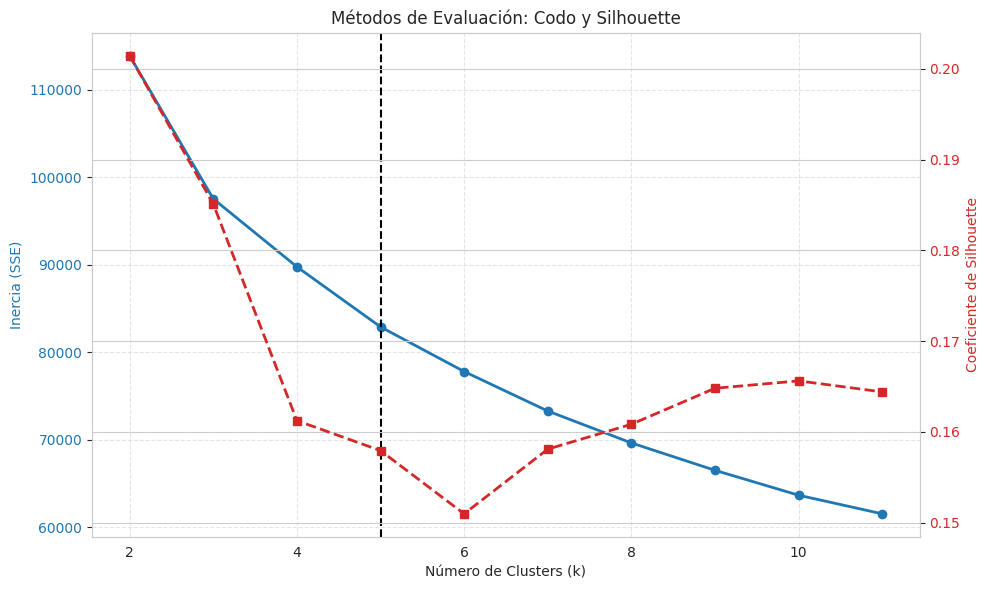

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (SSE)', color=color)
ax1.plot(rango_k, sse, marker='o', color=color, linewidth=2, label='Inercia')
if kl.elbow:
    ax1.axvline(x=kl.elbow, color='black', linestyle='--', label=f'Codo detectado (k={kl.elbow})')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silhouette', color=color)
ax2.plot(rango_k, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Métodos de Evaluación: Codo y Silhouette')
fig.tight_layout()
plt.show()


#### === INTERPRETACIÓN GRÁFICO CODO + SILHOUETTE ===
#### - La curva azul (Inercia) desciende pronunciadamente hasta k=5 y luego se aplana → punto de "codo"
#### - La curva roja (Silhouette) alcanza su valor máximo en k=2 (0.20), pero cae hacia k=5 (0.157)
#### - El método del codo sugiere k=5 como punto de inflexión óptimo
#### - El Silhouette repunta levemente desde k=8 en adelante (0.165), sin superar el valor de k=2
#### - Se elige k=5 como balance entre compacidad de clusters y ganancia marginal decreciente de inercia


---
## 3.4 Entrenamiento del Modelo Final

In [ ]:
k_optimo = kl.elbow
modelo = KMeans(n_clusters=k_optimo, init='k-means++', max_iter=300, n_init=10, random_state=42)
modelo.fit(X_scaled)
df['cluster'] = modelo.predict(X_scaled)

print('--- Cantidad de desastres por cluster ---')
print(df['cluster'].value_counts().sort_index())

--- Cantidad de desastres por cluster ---
cluster
0    2817
1    1722
2    3971
3    5401
4    3880
Name: count, dtype: int64


---
## 3.5 Perfil de Cada Cluster

In [ ]:
print('--- Perfil promedio por cluster ---\n')
perfil = df.groupby('cluster')[['Total Deaths', 'No. Affected', 'Total Affected', 'CPI']].mean().round(1)
print(perfil.to_string())

# Usamos df_original para recuperar los nombres reales
df_original = pd.read_excel('/content/sample_data/Natural-Disaster.xlsx')
df_original['cluster'] = df['cluster'].values

print('\n--- Tipo de desastre más frecuente por cluster ---\n')
for i in range(k_optimo):
    top_tipo = df_original[df_original['cluster'] == i]['Disaster Type'].value_counts().head(3)
    top_region = df_original[df_original['cluster'] == i]['Region'].value_counts().head(2)
    print(f'CLUSTER {i}:')
    print(f'  Tipos    : {", ".join(top_tipo.index.tolist())}')
    print(f'  Regiones : {", ".join(top_region.index.tolist())}')
    print()

--- Perfil promedio por cluster ---

         Total Deaths  No. Affected  Total Affected   CPI
cluster                                                  
0              3149.1     2070829.3       2117083.8  36.7
1             17888.1         712.7          7303.5  11.4
2               166.0         162.3          5275.6  62.3
3                43.0      549787.0        551839.3  74.7
4                20.4         323.3          5636.5  61.1

--- Tipo de desastre más frecuente por cluster ---

CLUSTER 0:
  Tipos    : Flood, Storm, Epidemic
  Regiones : Asia, Africa

CLUSTER 1:
  Tipos    : Storm, Earthquake, Flood
  Regiones : Asia, Americas

CLUSTER 2:
  Tipos    : Flood, Epidemic, Extreme temperature
  Regiones : Asia, Africa

CLUSTER 3:
  Tipos    : Flood, Storm, Earthquake
  Regiones : Asia, Americas

CLUSTER 4:
  Tipos    : Storm, Mass movement (wet), Wildfire
  Regiones : Asia, Americas



#### === INTERPRETACIÓN DE CLUSTERS (k=5) ===
####
#### CLUSTER 0 — "Desastres Humanitarios Masivos"
#### - ~3.149 muertes y ~2,1M afectados
#### - CPI 36,7 → relativamente antiguos
#### - Inundaciones, Tormentas y Epidemias (Asia y África)
####
#### CLUSTER 1 — "Desastres Históricos Letales"
#### - ~17.888 muertes (el más mortífero)
#### - Muy pocos afectados registrados
#### - CPI 11,4 → los más antiguos
#### - Tormentas, Terremotos e Inundaciones (Asia y América)
####
#### CLUSTER 2 — "Desastres Recientes de Bajo Impacto"
#### - ~166 muertes y pocos afectados
#### - CPI 62,3 → eventos recientes
#### - Inundaciones, Epidemias y Temperaturas Extremas
####
#### CLUSTER 3 — "Desastres Modernos de Gran Escala"
#### - Solo ~43 muertes pero ~552 mil afectados
#### - CPI 74,7 → los más recientes
#### - Inundaciones, Tormentas y Terremotos
####
#### CLUSTER 4 — "Desastres Moderados Recientes"
#### - ~20 muertes y pocos afectados
#### - CPI 61,1 → eventos recientes
#### - Tormentas, Deslizamientos e Incendios Forestales
####
#### Conclusión: el modelo separó principalmente los desastres por
#### mortalidad, cantidad de afectados y antigüedad del evento.
#### Destacan los desastres históricos muy letales (Cluster 1),
#### los humanitarios masivos (Cluster 0) y los modernos con muchos
#### afectados pero baja mortalidad (Cluster 3).

---
## 3.6 Visualización de Clusters (PCA 2D)

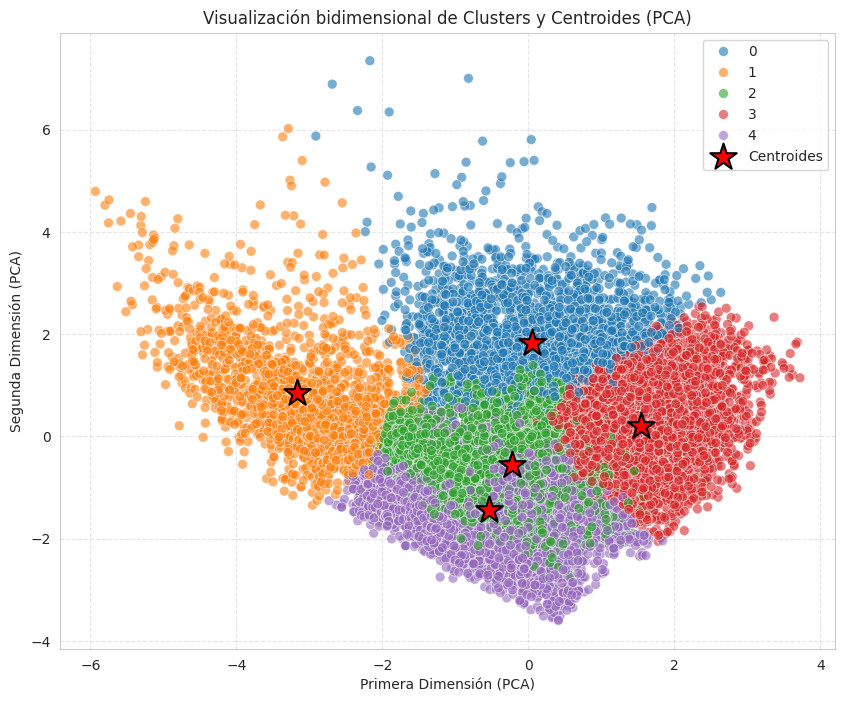

In [ ]:
pca = PCA(n_components=2)
datos_2d = pca.fit_transform(X_scaled)
centroides_2d = pca.transform(modelo.cluster_centers_)

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=datos_2d[:, 0],
    y=datos_2d[:, 1],
    hue=modelo.labels_,
    palette='tab10',
    alpha=0.6,
    s=50
)

plt.scatter(
    centroides_2d[:, 0],
    centroides_2d[:, 1],
    c='red',
    marker='*',
    s=400,
    label='Centroides',
    edgecolors='black',
    linewidths=1.5
)

plt.title('Visualización bidimensional de Clusters y Centroides (PCA)')
plt.xlabel('Primera Dimensión (PCA)')
plt.ylabel('Segunda Dimensión (PCA)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#### === INTERPRETACIÓN VISUALIZACIÓN PCA ===
#### Se redujo el espacio de 7 dimensiones a 2 usando PCA para poder visualizar.
#### Cada color representa un cluster. Las estrellas rojas son los centroides.
#### Los clusters bien separados indican que K-Means encontró grupos reales.
#### Clusters solapados indican desastres con características similares
#### que el modelo aún así logró distinguir en el espacio original de 7D.


---
# FASE 4: Evaluación

## 4.1 Justificación Técnica del Modelo


#### === JUSTIFICACIÓN TÉCNICA: ¿POR QUÉ K-MEANS? ===
####
#### Se eligió K-Means por las siguientes razones técnicas:
---
#### 1. El dataset NO tiene variable objetivo etiquetada
####    → K-Means es el algoritmo de clustering más adecuado para este caso
---
#### 2. Las variables numéricas permiten calcular distancias euclidianas
####    → Total Deaths, No. Affected, Total Affected, CPI, fechas
####    → K-Means usa exactamente esto para agrupar
---
#### 3. Escala manejable: 17.791 registros × 7 variables
####    → K-Means es eficiente computacionalmente en esta escala
---
####
#### 4. Objetivo exploratorio: descubrir patrones ocultos




---
## 4.2 Análisis de Resultados

#### === ANÁLISIS DE RESULTADOS ===
####
#### El modelo K-Means con k=5 identificó cinco perfiles de desastres
#### diferenciados principalmente por mortalidad, cantidad de afectados
#### y antigüedad del evento.
---
#### - Cluster 0 concentra los desastres de mayor impacto humanitario.
####   Registra más de 2,1 millones de afectados en promedio y predominan
####   inundaciones, tormentas y epidemias en Asia y África.
---
#### - Cluster 1 agrupa los desastres históricos más letales.
####   Presenta la mayor cantidad de muertes (~17.888) y el CPI más bajo (11,4),
####   indicando eventos muy antiguos con escasos registros de afectados.
---
#### - Clusters 2 y 4 representan desastres recientes de menor impacto,
####   caracterizados por bajas cifras de muertes y afectados.
---
#### - Cluster 3 agrupa eventos recientes con gran cantidad de afectados
####   (552 mil) pero baja mortalidad (43 muertes), reflejando mejores
####   sistemas de prevención y respuesta.
---
#### La variable CPI fue clave para diferenciar eventos históricos
#### (CPI bajo) de eventos más recientes (CPI alto).

#### Asia concentra la mayor presencia de desastres en todos los clusters,
#### seguida por América y África, destacando como las regiones más
#### expuestas a eventos naturales extremos.

NameError: name 'df' is not defined